In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler

In [10]:
data = pd.read_csv('loan.csv')
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95,360.0,1.0,Urban,Y


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    int64  
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(3), int64(2), object(8)
memory usage: 38.8+ KB


In [14]:
data.Dependents.unique()

array([ 1.,  0.,  2.,  3., nan])

In [13]:
data.Dependents.replace(['1', '0', '2', '3+'], [1,0,2,3], inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_34232\1967782580.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Dependents.replace(['1', '0', '2', '3+'], [1,0,2,3], inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_34232\1967782580.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data

In [33]:
data.Dependents.dtype

dtype('float64')

In [34]:
data.Education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [35]:
data.Self_Employed.unique()

array(['No', 'Yes', nan], dtype=object)

In [36]:
data.Property_Area.unique()

array(['Rural', 'Urban', 'Semiurban'], dtype=object)

In [37]:
data.Loan_Status.unique()

array(['N', 'Y'], dtype=object)

In [38]:
data.drop('Loan_ID',axis=1, inplace=True)

In [39]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1.0,Graduate,No,4583,1508.0,128,360.0,1.0,Rural,N
1,Male,Yes,0.0,Graduate,Yes,3000,0.0,66,360.0,1.0,Urban,Y
2,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120,360.0,1.0,Urban,Y
3,Male,No,0.0,Graduate,No,6000,0.0,141,360.0,1.0,Urban,Y
4,Male,Yes,0.0,Not Graduate,No,2333,1516.0,95,360.0,1.0,Urban,Y


In [40]:
X = data.drop("Loan_Status",axis=1)
y = data.Loan_Status

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size=0.20, random_state=42)

In [57]:
cat_cols = X_train.select_dtypes('object')
num_cols = X_train.select_dtypes('number')

In [43]:
cat_cols

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'], dtype='object')

In [44]:
num_cols

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [45]:
model  = LogisticRegression()

In [68]:
#  Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # handle missing numbers
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # handle missing categories
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False))
])

In [69]:
preprocessor = ColumnTransformer(
                            transformers=[
                            ("num", num_pipeline, num_cols.columns),
                            ("cat", cat_pipeline, cat_cols.columns)
                            ])

In [70]:
model_pipeline = Pipeline(
    [
    ("preprocessor",  preprocessor),
    ("model", model)
    ]
)

model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


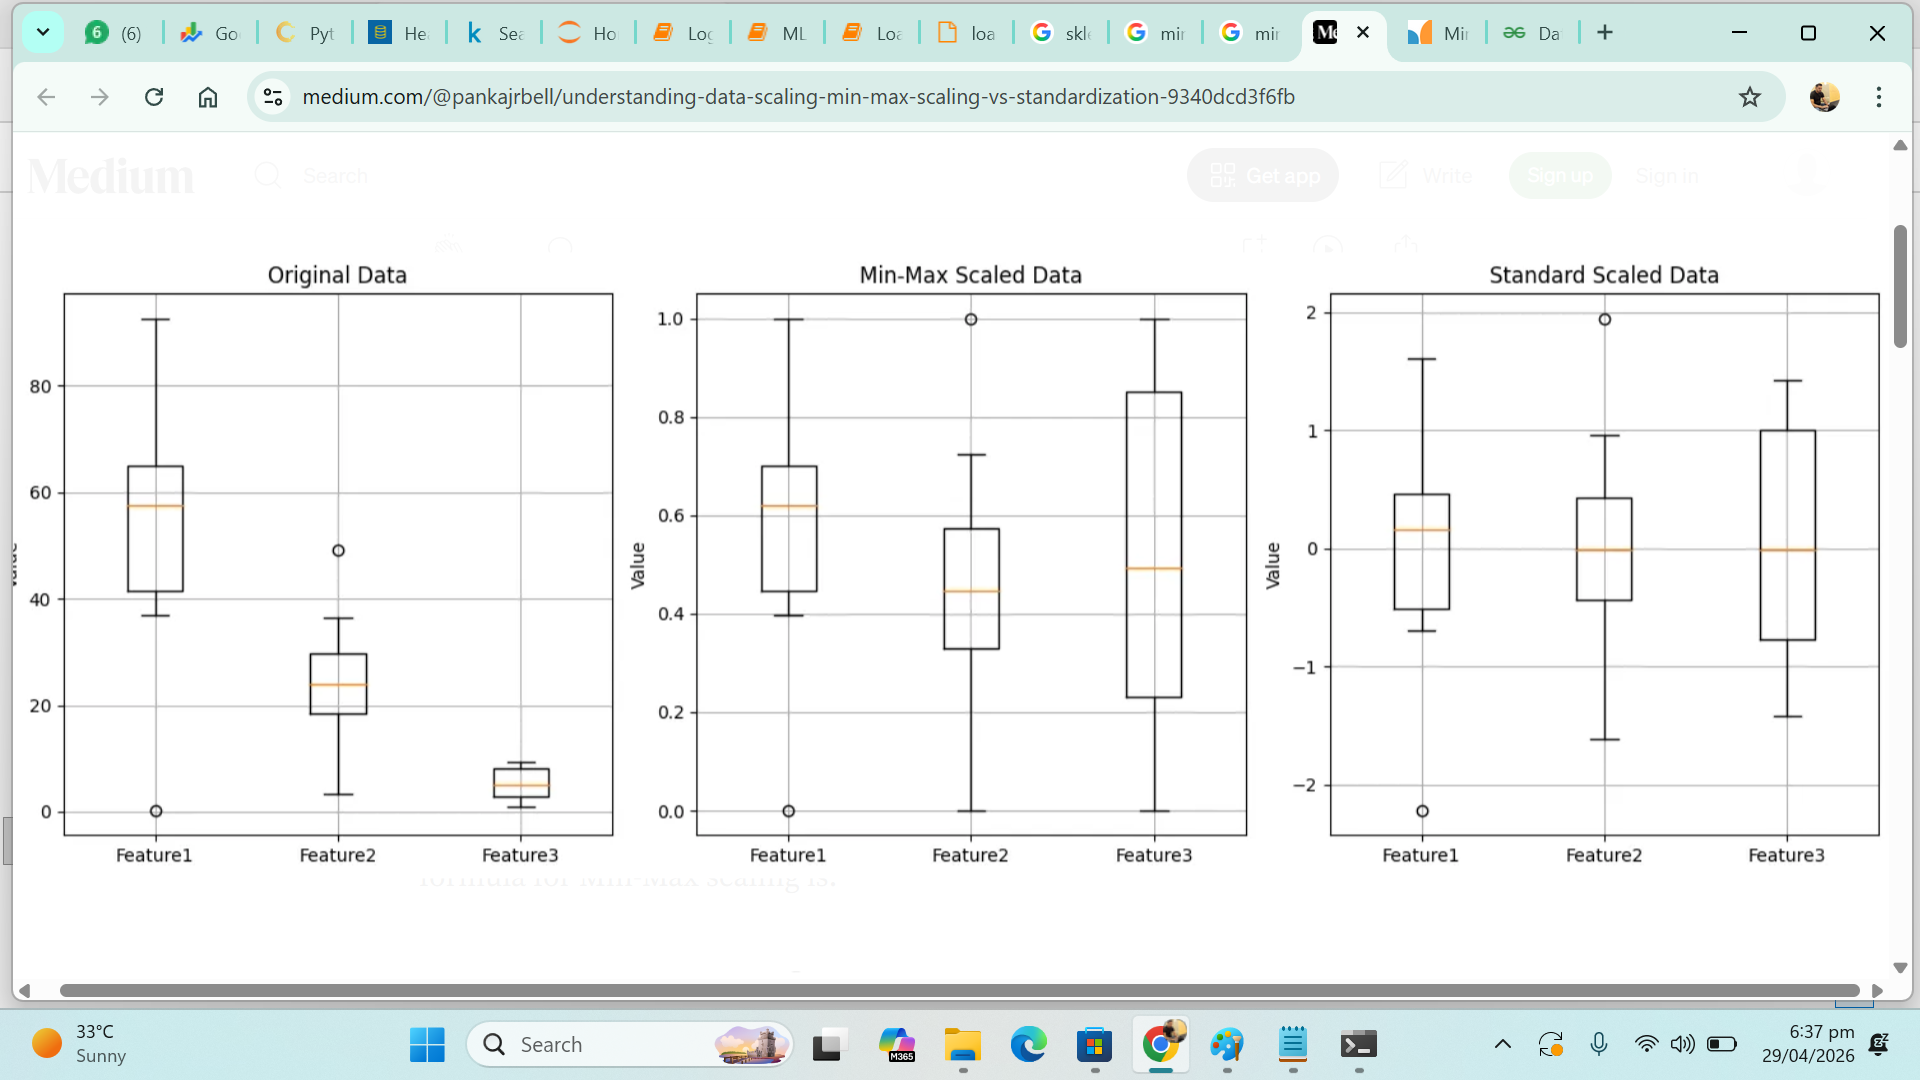


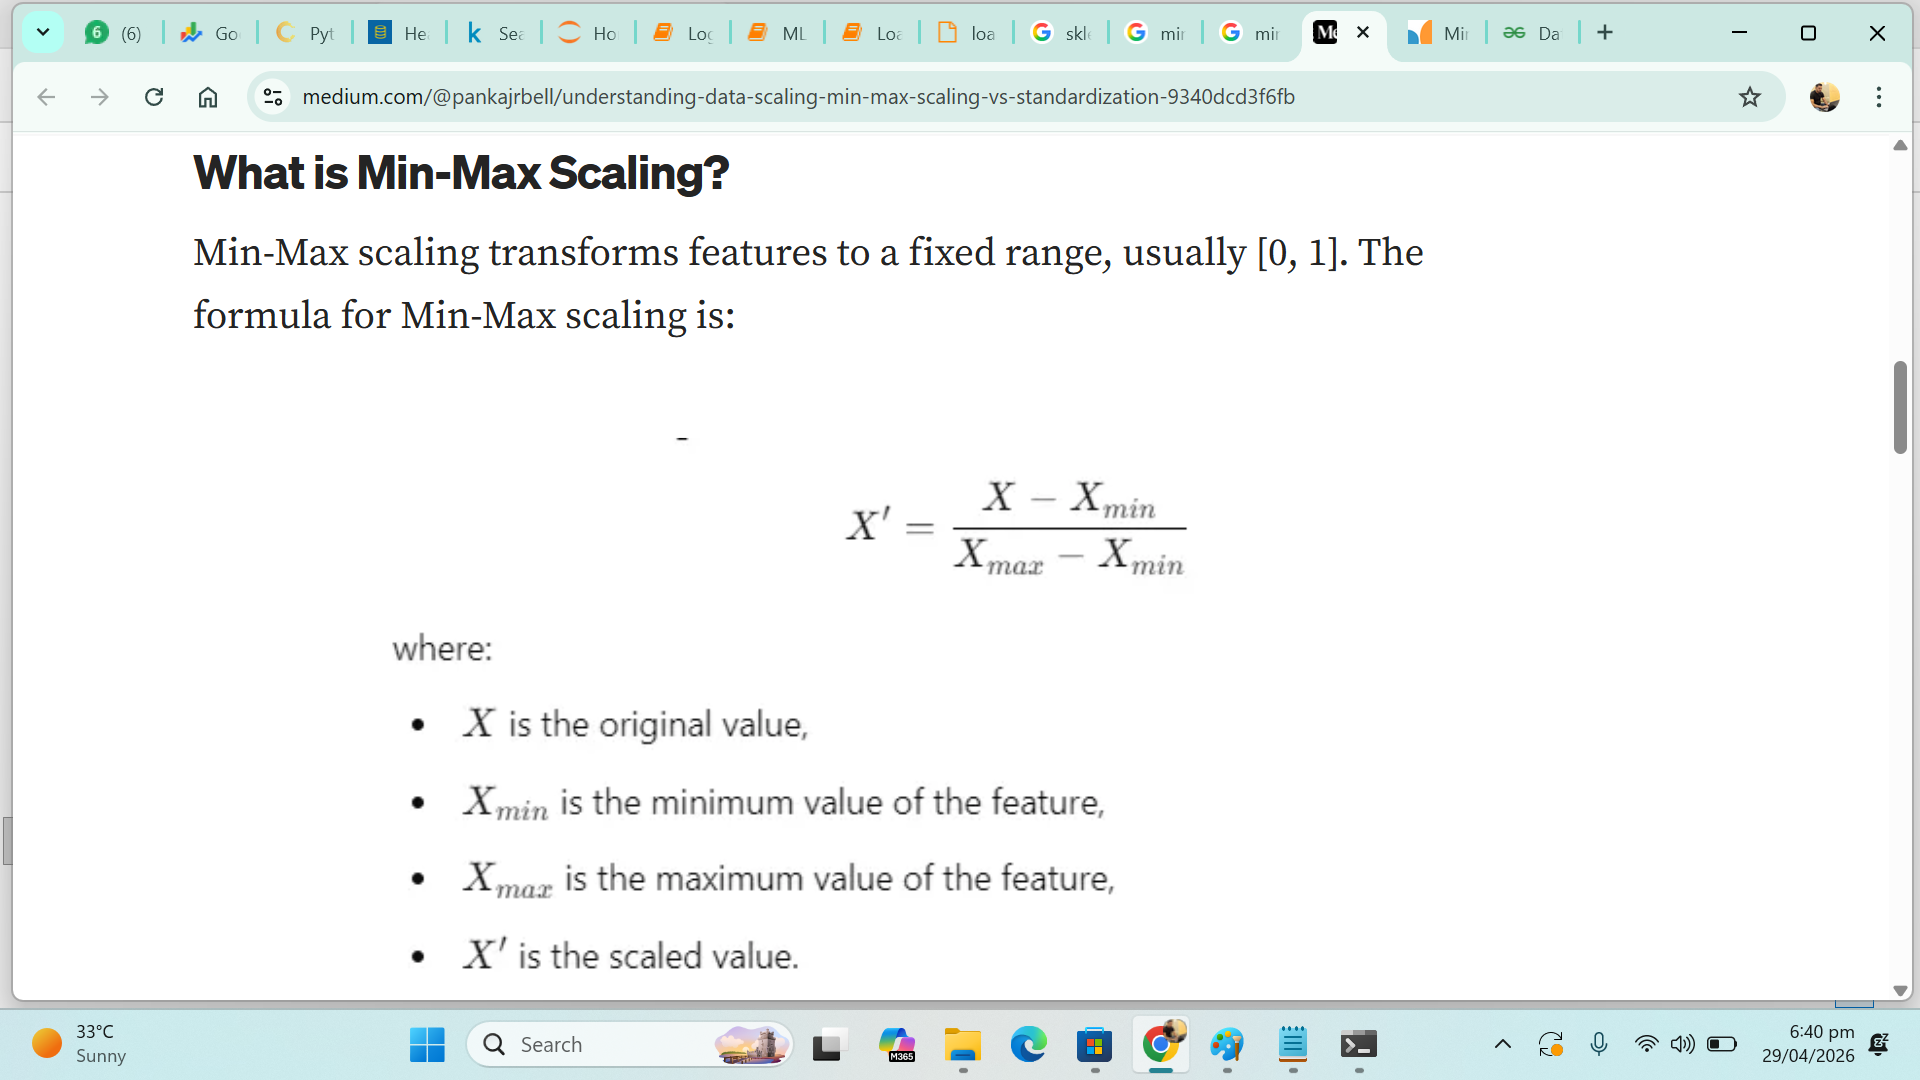

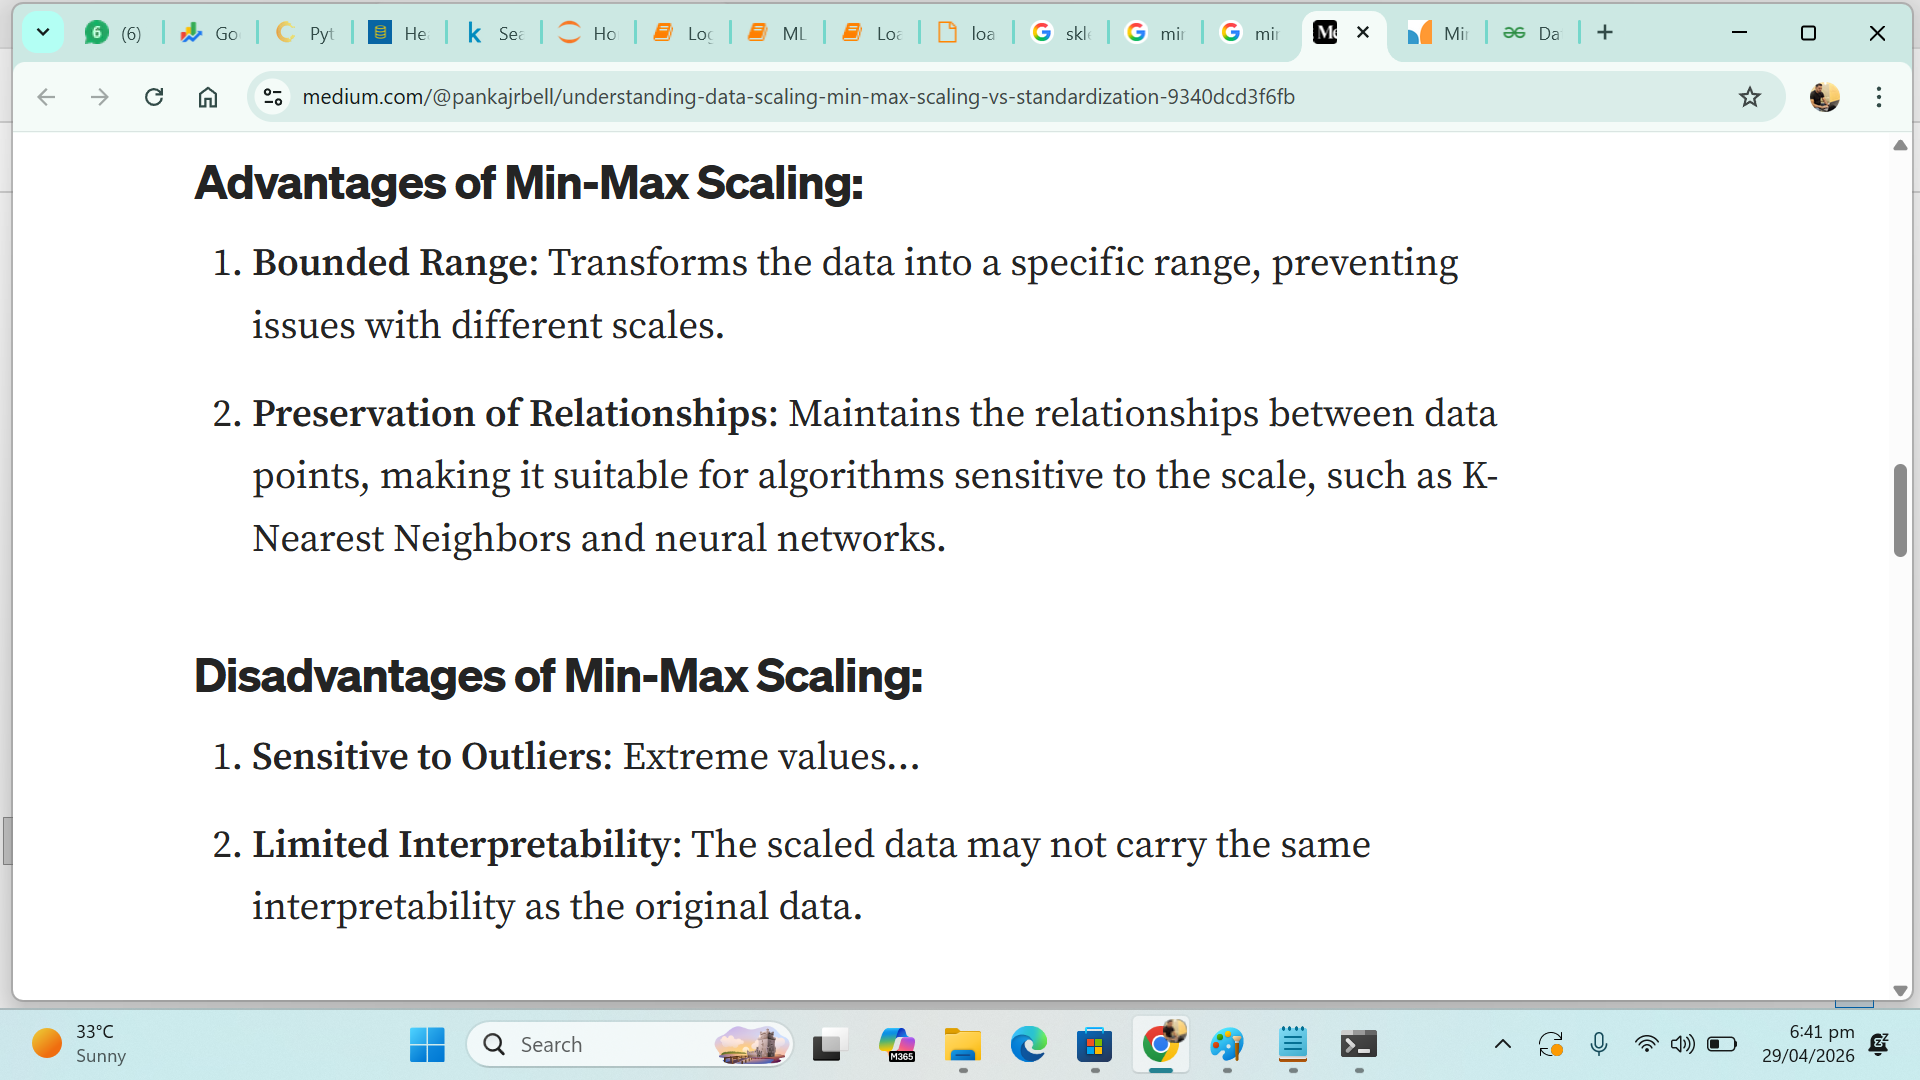

In [60]:
(num_cols - num_cols.min()) / (num_cols.max()-num_cols.min())

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
78,0.000000,0.416728,0.00000,0.203008,0.74359,1.0
265,0.000000,0.319815,0.07085,0.909774,0.74359,1.0
93,0.000000,0.639102,0.00000,0.759398,0.74359,0.0
377,0.000000,0.318340,0.09750,0.684211,0.74359,1.0
272,0.666667,0.603076,0.00000,0.872180,0.74359,1.0
...,...,...,...,...,...,...
71,0.333333,0.299378,0.05150,0.624060,0.74359,1.0
106,0.000000,0.346255,0.09820,0.744361,0.74359,1.0
270,0.000000,0.258717,0.21500,0.781955,0.74359,1.0
348,0.000000,0.271253,0.10080,0.699248,0.74359,1.0


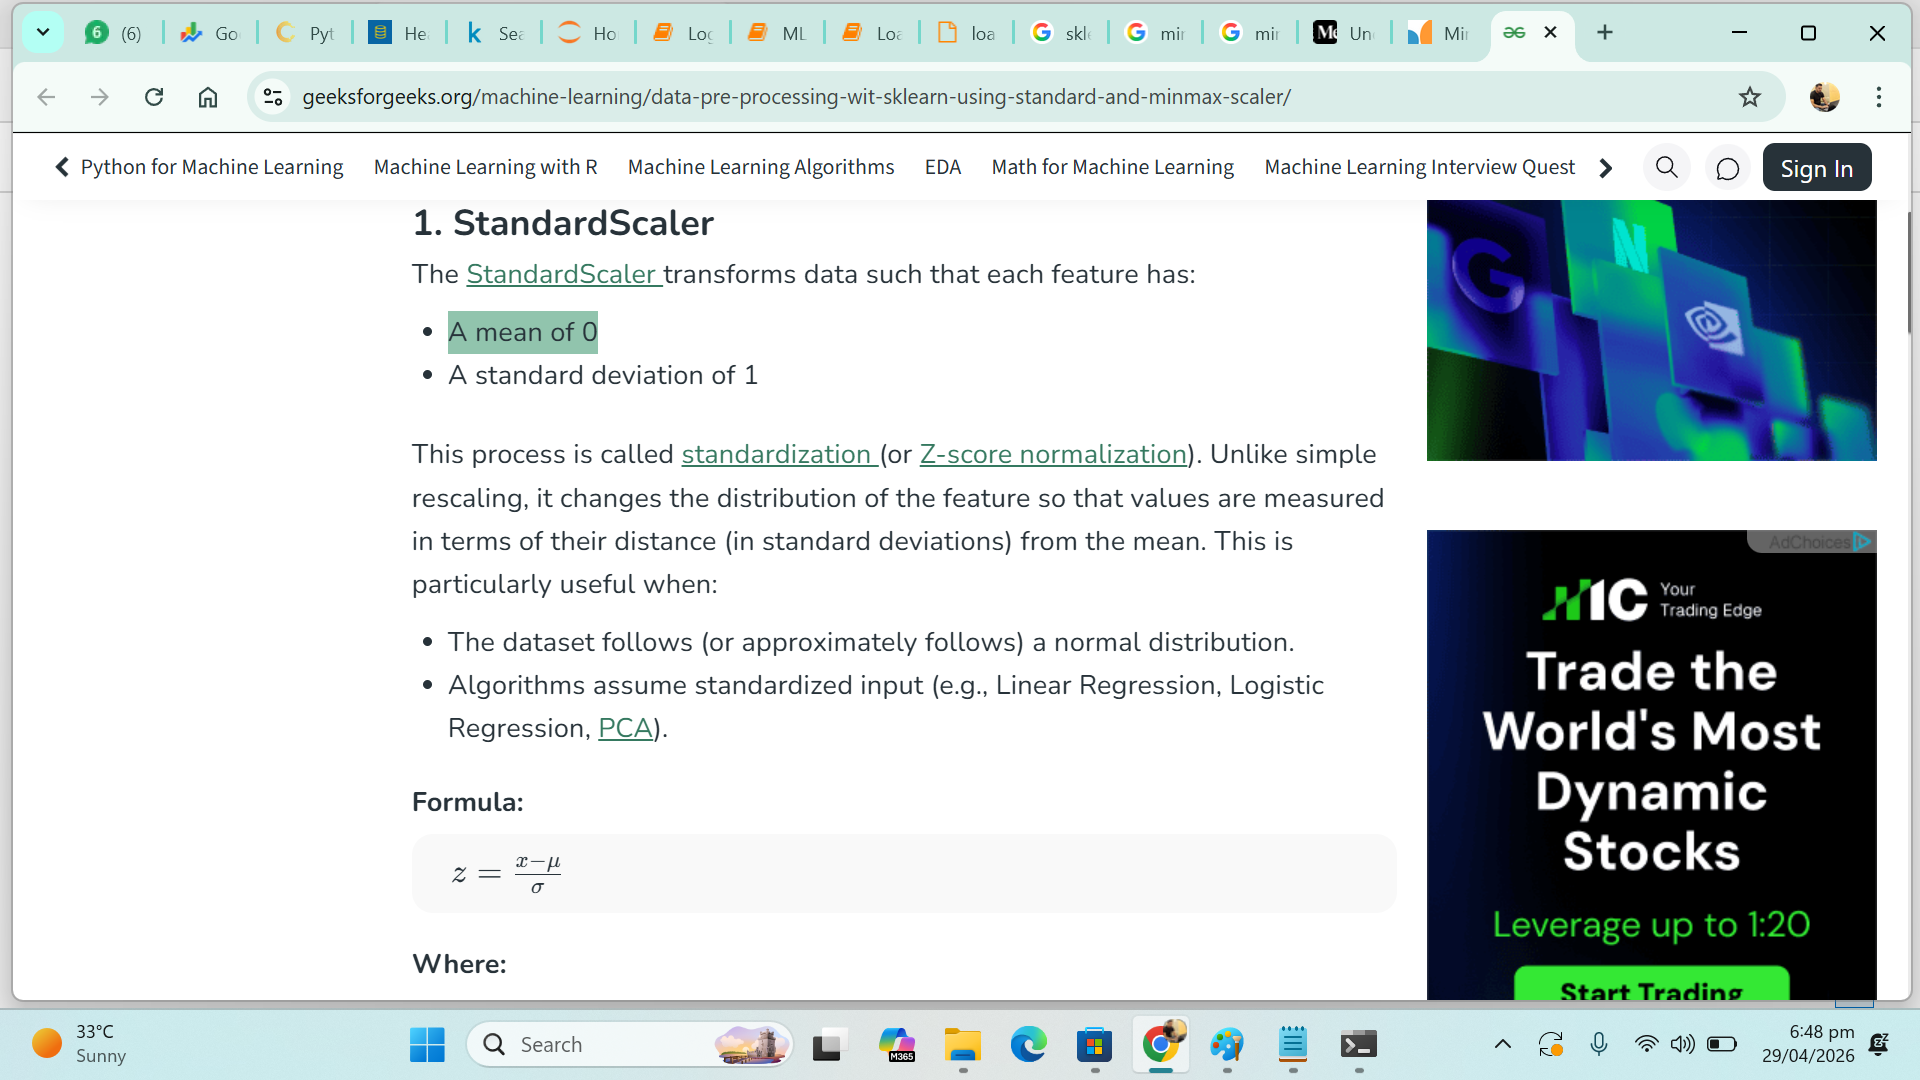

In [66]:
((num_cols - num_cols.mean()) / num_cols.std())['Dependents'].mean()

np.float64(-8.971499188890154e-17)

In [67]:
((num_cols - num_cols.mean()) / num_cols.std())['Dependents'].std()

0.9999999999999988

Min-Max Scaling (Normalization):
When to use: When your algorithm requires a specific, bounded range (e.g., image data to ), for image processing/pixel data, or distance-based models where you know the exact minimum/maximum values.
Pros: Keeps data bounded to a range (usually or to ); maintains the shape of the original distribution.
Cons: Highly sensitive to outliers; a single large outlier can squeeze all other values into a tiny, ineffective range.
Standardization (Z-score Scaling):
When to use: When your algorithm assumes data is Gaussian (e.g., Linear/Logistic Regression, Linear Discriminant Analysis) or for models sensitive to outliers (e.g., Support Vector Machines).
Pros: Handles outliers much better than min-max and results in a mean of 0 and standard deviation of 1, helping gradient descent converge faster.
Cons: Does not produce a "bounded" range (e.g., output can be 
 to 
), which can violate assumptions for certain models that require inputs within a strict 

 range (like sigmoid functions in neural networks)

In [71]:
model_pipeline.predict(X_test)

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y'],
      dtype=object)

In [72]:
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [73]:
import pickle

In [74]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model_pipeline, f)

In [78]:
d = data.sample(5).drop('Loan_Status',axis=1)

In [79]:
d.to_csv('testingdata.csv')